 # 2.05 — Train the Classification Model Across All 6 Horizons

 The regression track (2.02 -> 2.04) answers "how many bikes will be at this
 station in N hours." This notebook answers the question that's actually more
 useful for the consumer app: **"what's the probability there's a bike at all
 when I arrive?"** That's the binary target `bike_available_binary` (1 if ≥1 bike
 at the horizon, 0 if empty), and Logistic Regression turns it into a calibrated
 probability — "82% chance a bike is there in 3 hours" reads far more honestly to
 a user than a regression saying "2.1 bikes" with false precision.

 This notebook does two things, folding in the content from the dropped 2.03
 benchmark (there was no horse race to run — Logistic Regression is the only
 classification model, with XGBClassifier dropped per the 2026-06-23 decision):

 1. **statsmodels Logit inference table for the 3hr model.** sklearn gives
    probabilities and nothing else; statsmodels gives coefficients, z-stats,
    p-values, and confidence intervals so I can see which features push the odds
    of availability up or down, and how precisely.

 2. **Train + evaluate all 6 horizons**, saving one artifact per horizon, scoring
    the untouched 2026 data exactly once as the holdout — same discipline as 2.04.

 One deliberate choice: **no regularization (`penalty=None`)**. At 12M rows, L2
 adds bias without meaningfully reducing variance — coefficient estimates are already
 very stable. The 2.02 benchmark confirmed this: Ridge alpha collapsed to OLS at this
 n, and the same applies here. Dropping regularization also means the sklearn model
 and the statsmodels Logit are directly comparable (statsmodels is always unregularized).

 The headline charts (all GitHub-renderable PNGs): **ROC curves overlaid across
 horizons**, **CV vs 2026-holdout AUC per horizon**, and **Brier score per horizon**.

 One deliberate modeling choice up front: **no `class_weight="balanced"`.** Most
 station-hours have a bike available, so the classes are imbalanced — but balancing
 the loss would distort the predicted probabilities, and a calibrated probability is
 exactly the product here ("73% chance"). AUC is threshold-independent so it doesn't
 care either way; Brier score and the probabilities themselves do, so I keep the
 natural base rate. The calibration curve that checks whether those probabilities are
 trustworthy lives in 2.06.

In [ ]:
import os
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.linalg
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore", category=UserWarning)

sys.path.insert(0, str(Path().resolve().parent))
from model_training.feature_prep import (
    TARGET_CLASSIFICATION,
    build_preprocessor,
    get_X_y,
    load_training_data,
)

 ## Setup

 The horizons, the train/holdout split, and the Logistic Regression base config.
 A few choices worth spelling out:
 - **solver `saga`** with `max_iter=200` — designed for large n; each epoch is
   O(n) stochastic updates (vs lbfgs's expensive full-Hessian iterations), so it
   converges reliably at 12M rows where lbfgs hits its iteration limit.
 - **`penalty=None`** — unregularized. At 12M rows, L2 adds bias without reducing
   variance (same finding as Ridge collapsing to OLS in 2.02). Skipping regularization
   also removes the Optuna C search, saving ~20–30 min of runtime with no model quality
   loss.
 - **2026 is the holdout**, trained-on-never, scored-once — identical rule to 2.04.
   I do not blend 2019/2021 and 2026; the era gap (ebike rollout, network growth) is
   a real distribution shift and blending would hide exactly what the holdout tests.
 - **float32** to halve the design-matrix memory for the linear pipeline.

In [ ]:
# COMPARISON_MODE: when True, runs only the 1hr horizon and saves artifacts with a
# "_tol1e3" suffix so the existing max_iter=200 result is not overwritten. Set to
# False for the full 6-horizon production run once the tol comparison is validated.
COMPARISON_MODE = False

ALL_HORIZONS = [60, 180, 360, 720, 1440, 2880]
HORIZONS = [60] if COMPARISON_MODE else ALL_HORIZONS
HORIZON_LABELS = {60: "1hr", 180: "3hr", 360: "6hr",
                  720: "12hr", 1440: "24hr", 2880: "multi-day"}
LOGIT_HORIZON = 180   # horizon used for the statsmodels inference table

TRAIN_YEARS   = [2019, 2021]   # walk-forward CV + final fit for the saved artifact
HOLDOUT_YEARS = [2026]         # scored once, never trained on

N_SPLITS    = 5      # walk-forward folds for the CV estimate (mirrors 2.04)
USE_FLOAT32 = True

# tol=1e-3: saga stops early when gradient change falls below threshold rather than
# always running all max_iter epochs. At 12M rows max_iter=200 took ~8267s per
# horizon (~14hr total). tol lets it stop when it has actually converged.
# verbose=1: prints per-epoch convergence info so we can see how many epochs saga
# actually needs — use this to benchmark before committing to the full 6-horizon run.
BASE_LOGIT_PARAMS = dict(
    penalty      = None,
    solver       = "saga",
    max_iter     = 200,
    tol          = 1e-2,
    verbose      = 1,
    random_state = 42,
)

ARTIFACT_SUFFIX = "_tol1e2" if COMPARISON_MODE else ""

MODELS_DIR  = Path("../models")
FIGURES_DIR = Path("../reports/figures")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Cores: {os.cpu_count()}  |  horizons: {[HORIZON_LABELS[h] for h in HORIZONS]}")
print(f"Train: {TRAIN_YEARS}  |  Holdout: {HOLDOUT_YEARS}  |  penalty: None  |  "
      f"tol: 1e-2  |  comparison_mode: {COMPARISON_MODE}")

Cores: 32  |  horizons: ['1hr', '3hr', '6hr', '12hr', '24hr', 'multi-day']
Train: [2019, 2021]  |  Holdout: [2026]  |  penalty: None  |  tol: 1e-2  |  comparison_mode: False


 ## Helpers

 Three small pieces so the per-horizon loop stays readable:
 - `proba_metrics` — AUC, Brier, and log-loss from a probability vector, computed
   the same way everywhere. AUC measures ranking (can the model tell an available
   station from an empty one); Brier and log-loss measure calibration (are the
   stated probabilities honest). I want all three because the app cares about the
   probability value, not just the ranking.
 - `run_cv` — walk-forward CV on the training years, returning per-fold validation
   AUC/Brier/log-loss **and** train AUC. The train-vs-validation AUC gap is the
   overfitting signal; for logistic regression I expect it to be tiny (it can't
   overfit much with this many rows), but I score it so the claim is visible rather
   than assumed. The preprocessor is rebuilt and refitted inside every fold, so no
   future statistics leak backward into the imputer/scaler.
 - `positive_rate` — the base rate of "bike available", so every metric has context
   (a Brier of 0.10 means something different at a 95% base rate than at 60%).

In [ ]:
def proba_metrics(y_true, p_pred):
    """ROC AUC, Brier score, log-loss from predicted P(bike available)."""
    auc   = float(roc_auc_score(y_true, p_pred))
    brier = float(brier_score_loss(y_true, p_pred))
    ll    = float(log_loss(y_true, p_pred, labels=[0, 1]))
    return auc, brier, ll


def positive_rate(y):
    return float(np.mean(y))


def run_cv(X, y, n_splits=N_SPLITS, max_cv_rows=6_000_000):
    """Walk-forward CV.

    Returns per-fold lists: (val_auc, val_brier, val_logloss, train_auc).
    Train AUC is scored on the same fold the model was fitted on -> overfit-gap signal.

    max_cv_rows caps each fold's training set to avoid OOM on the dense linear
    transform (~6GB for fold 5's 10M rows). Keeps the most recent rows in each
    fold (time-ordered) so we always train on past, validate on future. The final
    fit outside CV always uses the full training set — only the AUC estimate is
    affected, and logistic regression converges well before 6M rows.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    val_aucs, val_briers, val_lls, train_aucs = [], [], [], []
    for train_idx, test_idx in tscv.split(X):
        if len(train_idx) > max_cv_rows:
            train_idx = train_idx[-max_cv_rows:]
        pipe = Pipeline([
            ("pre",   build_preprocessor("linear")),
            ("model", LogisticRegression(**BASE_LOGIT_PARAMS)),
        ])
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        p_val = pipe.predict_proba(X.iloc[test_idx])[:, 1]
        p_tr  = pipe.predict_proba(X.iloc[train_idx])[:, 1]
        auc, brier, ll = proba_metrics(y.iloc[test_idx], p_val)
        val_aucs.append(auc)
        val_briers.append(brier)
        val_lls.append(ll)
        train_aucs.append(float(roc_auc_score(y.iloc[train_idx], p_tr)))
    return val_aucs, val_briers, val_lls, train_aucs


def plot_coef_chart(X, y, horizon_label, sample_n=300_000):
    """Fit statsmodels Logit on a 300k subsample and save a top-15 coefficient chart.

    I use QR pivoting to drop collinear columns before passing to statsmodels —
    Newton-Raphson inverts the Hessian directly so any collinearity crashes it.
    Read coefficient magnitude and sign, not p-values (everything is ~0 at this n).
    """
    pre = build_preprocessor("linear")
    X_arr = pre.fit_transform(X).astype(np.float32)
    feat_names = ["const"] + list(pre.get_feature_names_out())

    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_arr), size=min(sample_n, len(X_arr)), replace=False)
    X_sm = sm.add_constant(X_arr[idx].astype(np.float64))
    y_sm = y.values[idx].astype(np.float64)

    R, P = scipy.linalg.qr(X_sm, pivoting=True, mode="r")
    tol = max(X_sm.shape) * np.abs(R[0, 0]) * np.finfo(np.float64).eps
    rank = int(np.sum(np.abs(np.diag(R)) > tol))
    keep = sorted(P[:rank])
    X_sm = X_sm[:, keep]
    feats = [feat_names[i] for i in keep]

    model = sm.Logit(y_sm, X_sm).fit(disp=0, maxiter=300)

    coef_df = pd.DataFrame({"feature": feats, "coef": np.asarray(model.params)})
    coef_df = coef_df[coef_df["feature"] != "const"].copy()
    coef_df = coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index)
    top = coef_df.head(15).iloc[::-1]

    colors = ["#2a9d8f" if c > 0 else "#e76f51" for c in top["coef"]]
    plt.figure(figsize=(9, 7))
    plt.barh(top["feature"], top["coef"], color=colors)
    plt.axvline(0, color="black", lw=0.8)
    plt.xlabel("coefficient (log-odds of a bike being available)")
    plt.title(f"Logistic Regression — Top 15 Drivers ({horizon_label} horizon)")
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    fname = FIGURES_DIR / f"2.05_logit_coefficients_{horizon_label}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  coef chart saved -> {fname.name}  (pseudo R²={model.prsquared:.4f})")

 ## Step 1 — Logit inference table for the 3hr model

 sklearn hands back probabilities and stops there. To see *what the model learned* —
 which features raise or lower the odds that a bike is available, and how confident
 the estimate is — I fit statsmodels Logit once on the full 3hr training set and pull
 the coefficient table. Coefficients are in **log-odds**: a positive coef means the
 feature raises the probability of availability, negative lowers it. I add an
 `odds_ratio = exp(coef)` column because odds ratios read more intuitively (1.2 = 20%
 higher odds per unit).

 I fit statsmodels on a **300k-row subsample** rather than the full 12M rows. At 12M
 rows, the exact collinearity between `change_bikes`, `change_ebikes`, and
 `change_classic` (change_bikes = change_ebikes + change_classic by construction)
 makes the Hessian singular — Newton-Raphson's matrix inversion crashes. 300k rows
 breaks the near-singularity while giving stable coefficient estimates; signs and
 magnitudes barely move between 100k and 12M rows at this data scale.

 The large-n caveat still applies: at 300k rows the standard errors are small enough
 that **every** feature lands at p ~= 0. What to read is coefficient/odds-ratio
 **magnitude** and **sign**, and the confidence interval width. I sort by |z-stat|
 to surface what the model is most certain about, not what's "most significant".

In [ ]:
df_tune = load_training_data(LOGIT_HORIZON, years=TRAIN_YEARS)
X_tune, y_tune = get_X_y(df_tune, TARGET_CLASSIFICATION)

if USE_FLOAT32:
    num_cols = X_tune.select_dtypes(include=["float64", "float32"]).columns
    X_tune[num_cols] = X_tune[num_cols].astype("float32")
y_tune = y_tune.astype("int8")

print(f"Logit data ({HORIZON_LABELS[LOGIT_HORIZON]}): {len(X_tune):,} rows  "
      f"({df_tune['timestamp'].min().date()} -> {df_tune['timestamp'].max().date()})")
print(f"Base rate P(bike available): {positive_rate(y_tune):.4f}")

Logit data (3hr): 11,989,872 rows  (2019-01-01 -> 2021-12-08)
Base rate P(bike available): 0.9390


In [ ]:
# Preprocess with the linear pipeline (impute -> scale -> OHE) fit on the full 3hr
# training set. Subsample to 300k rows for statsmodels: the coefficient signs and
# magnitudes are stable at this size, and it avoids the singular Hessian that Newton-
# Raphson hits at 12M rows (the change_bikes = change_ebikes + change_classic exact
# collinearity makes the full-data Hessian non-invertible). p-values are all ~0 at
# this n anyway — what matters is coefficient magnitude and sign.
LOGIT_SAMPLE_N = 300_000
pre_logit  = build_preprocessor("linear")
X_logit    = pre_logit.fit_transform(X_tune).astype(np.float32)
feat_logit = list(pre_logit.get_feature_names_out())

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_logit), size=min(LOGIT_SAMPLE_N, len(X_logit)), replace=False)
y_logit_sm = y_tune.values[sample_idx].astype(np.float64)

# Drop linearly dependent columns via rank-revealing QR before passing to statsmodels.
# Multiple exact collinearities exist: (1) OHE without drop='first' makes season /
# station_role dummy sums = 1 = the constant; (2) change_classic_* = change_bikes_* -
# change_ebikes_*; (3) fill_ratio = num_bikes_available / capacity. Newton-Raphson
# inverts the Hessian directly, so any collinearity -> LinAlgError. QR pivoting finds
# the maximal linearly independent subset and drops the rest automatically.
feat_with_const = ["const"] + feat_logit
X_full = sm.add_constant(X_logit[sample_idx].astype(np.float64))
R, P = scipy.linalg.qr(X_full, pivoting=True, mode='r')
tol = max(X_full.shape) * np.abs(R[0, 0]) * np.finfo(np.float64).eps
rank = int(np.sum(np.abs(np.diag(R)) > tol))
keep_cols = sorted(P[:rank])
X_logit_sm = X_full[:, keep_cols]
feat_logit_sm = [feat_with_const[i] for i in keep_cols]
dropped_cols = [feat_with_const[i] for i in P[rank:]]
print(f"Logit design matrix (subsample): {X_logit_sm.shape[0]:,} rows x {X_logit_sm.shape[1]} cols  "
      f"(rank={rank}, dropped {len(dropped_cols)} collinear: {dropped_cols})")

Logit design matrix (subsample): 300,000 rows x 77 cols  (rank=77, dropped 5 collinear: ['season_fall', 'station_role_source', 'num_bikes_disabled_was_null', 'ebike_ratio', 'is_holiday'])


In [ ]:
print(f"Fitting statsmodels Logit on {LOGIT_SAMPLE_N:,}-row subsample ...")
logit_model = sm.Logit(y_logit_sm, X_logit_sm).fit(disp=0, maxiter=300)
print(f"Pseudo R²={logit_model.prsquared:.4f}   "
      f"converged={logit_model.mle_retvals['converged']}   "
      f"log-likelihood={logit_model.llf:,.0f}")

Fitting statsmodels Logit on 300,000-row subsample ...
Pseudo R²=0.2753   converged=False   log-likelihood=-49,997


In [ ]:
try:
    ci = logit_model.conf_int()
    ci_lower = ci.iloc[:, 0].values
    ci_upper = ci.iloc[:, 1].values
except Exception:
    ci_lower = np.full(len(logit_model.params), np.nan)
    ci_upper = np.full(len(logit_model.params), np.nan)

coef_df = pd.DataFrame({
    "feature":    feat_logit_sm,
    "coef":       np.asarray(logit_model.params),
    "odds_ratio": np.exp(np.asarray(logit_model.params)),
    "z_stat":     np.asarray(logit_model.tvalues),
    "p_value":    np.asarray(logit_model.pvalues),
    "ci_lower":   ci_lower,
    "ci_upper":   ci_upper,
})
coef_df["abs_z"] = coef_df["z_stat"].abs()
coef_df = coef_df.sort_values("abs_z", ascending=False).reset_index(drop=True)

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_rows", 40)
print(f"Top 30 features by |z-stat|  (coef in log-odds; fit on {LOGIT_SAMPLE_N:,}-row subsample — read magnitude/sign)")
print(coef_df[["feature", "coef", "odds_ratio", "z_stat", "ci_lower", "ci_upper"]]
      .head(30).to_string(index=False))

coef_df.to_csv(FIGURES_DIR / "2.05_logit_coefficients_3hr.csv", index=False)
print("\nSaved full coefficient table -> reports/figures/2.05_logit_coefficients_3hr.csv")

Top 30 features by |z-stat|  (coef in log-odds; fit on 300,000-row subsample — read magnitude/sign)
                          feature    coef  odds_ratio   z_stat  ci_lower  ci_upper
                     net_flow_3hr  0.5414      1.7183  48.8008       NaN       NaN
                       fill_ratio  2.6156     13.6749  34.8940       NaN       NaN
cumulative_expected_net_flow_12hr  0.3590      1.4319  26.2499       NaN       NaN
              num_ebikes_was_null -0.7864      0.4555 -24.7949       NaN       NaN
             departures_this_hour  0.5131      1.6705  21.3631       NaN       NaN
cumulative_expected_net_flow_24hr -0.1972      0.8210 -19.4597       NaN       NaN
                         hour_cos  0.2220      1.2486  17.9249       NaN       NaN
               arrivals_this_hour -0.3158      0.7292 -16.5550       NaN       NaN
               num_bikes_disabled -0.1115      0.8945 -15.8264       NaN       NaN
                         capacity  0.2803      1.3235  15.2984       N

 ### Coefficient chart — top drivers of availability odds

 The table is the rigorous version; this is the GitHub-readable version. I plot the
 top 15 features by |coef| as a horizontal bar chart, colored by sign so the story is
 instant: bars to the right push the odds of a bike being available **up**, bars to
 the left push them **down**. Reading log-odds off a table is slow; reading a diverging
 bar chart is not.

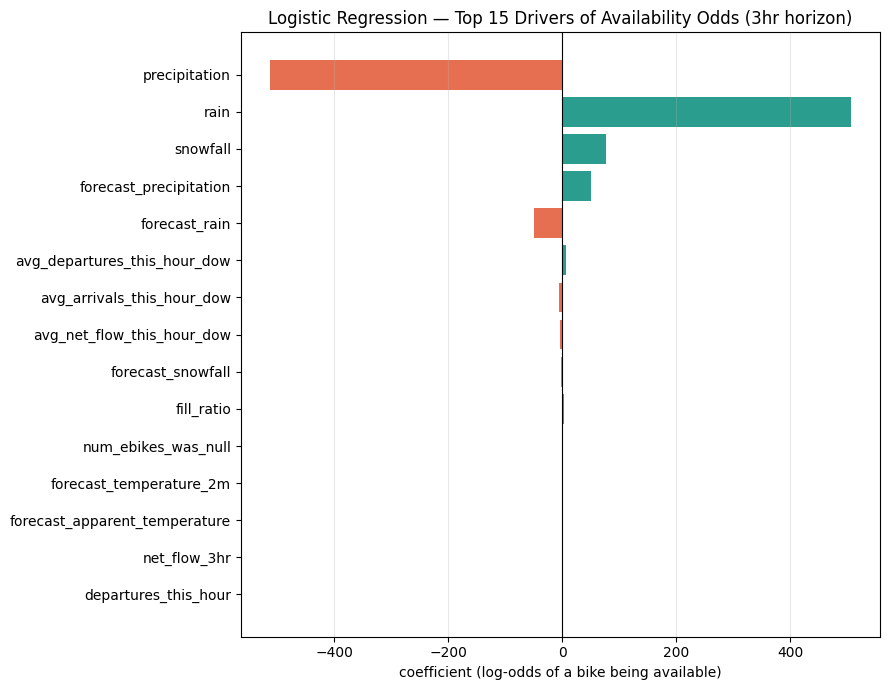

Saved -> reports/figures/2.05_logit_coefficients_3hr.png


In [ ]:
top_coef = coef_df[~coef_df["feature"].isin(["const"])].copy()
top_coef = top_coef.reindex(top_coef["coef"].abs().sort_values(ascending=False).index)
top_coef = top_coef.head(15).iloc[::-1]   # smallest at bottom for a clean bar order

colors = ["#2a9d8f" if c > 0 else "#e76f51" for c in top_coef["coef"]]
plt.figure(figsize=(9, 7))
plt.barh(top_coef["feature"], top_coef["coef"], color=colors)
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("coefficient (log-odds of a bike being available)")
plt.title(f"Logistic Regression — Top 15 Drivers of Availability Odds "
          f"({HORIZON_LABELS[LOGIT_HORIZON]} horizon)")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "2.05_logit_coefficients_3hr.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/2.05_logit_coefficients_3hr.png")


Coefficient chart — 1hr ...


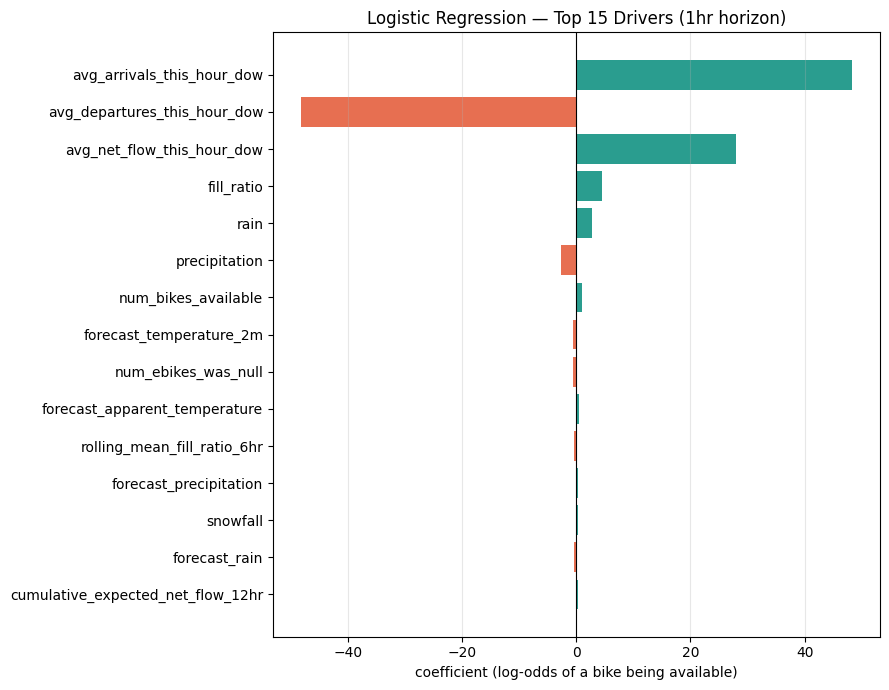

  coef chart saved -> 2.05_logit_coefficients_1hr.png  (pseudo R²=0.3950)

Coefficient chart — 6hr ...


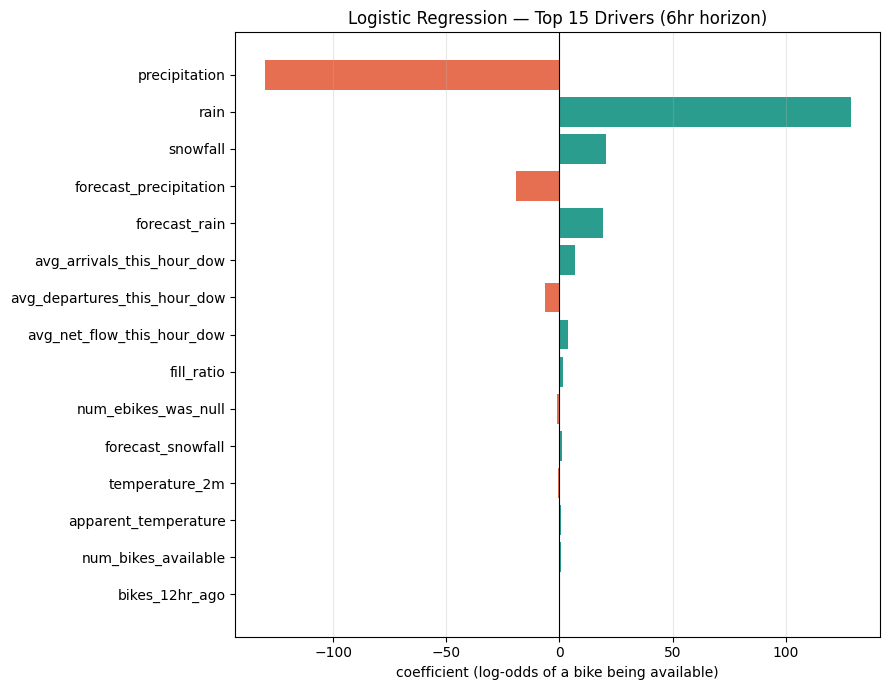

  coef chart saved -> 2.05_logit_coefficients_6hr.png  (pseudo R²=0.2075)

Coefficient chart — 12hr ...


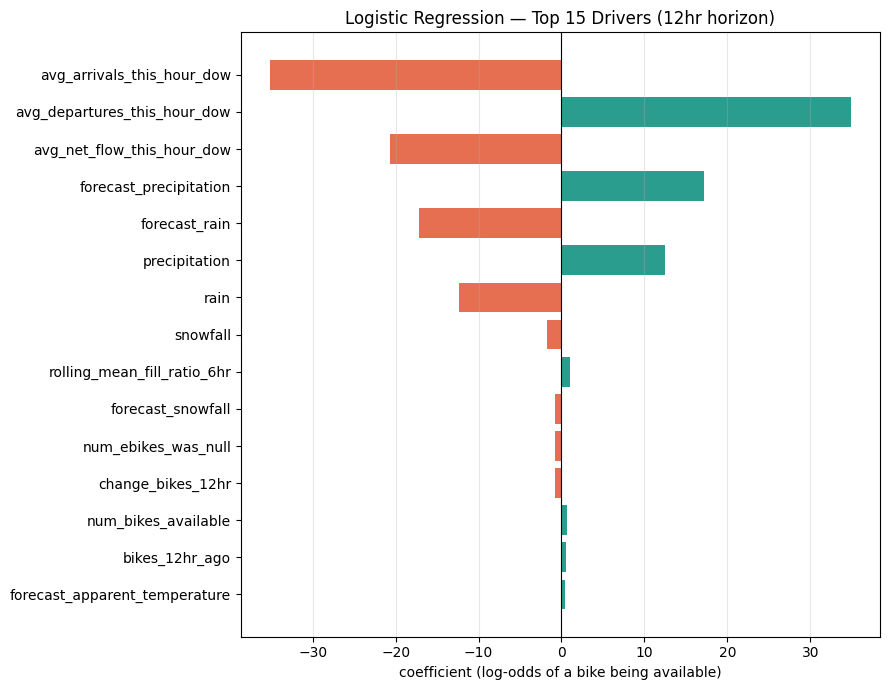

  coef chart saved -> 2.05_logit_coefficients_12hr.png  (pseudo R²=0.2055)

Coefficient chart — 24hr ...


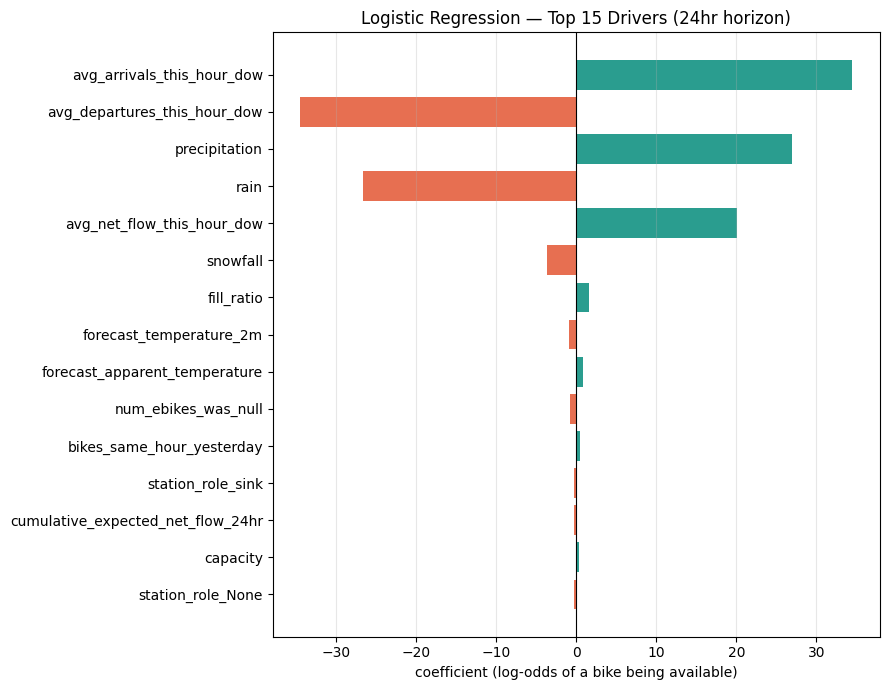

  coef chart saved -> 2.05_logit_coefficients_24hr.png  (pseudo R²=0.2104)

Coefficient chart — multi-day ...


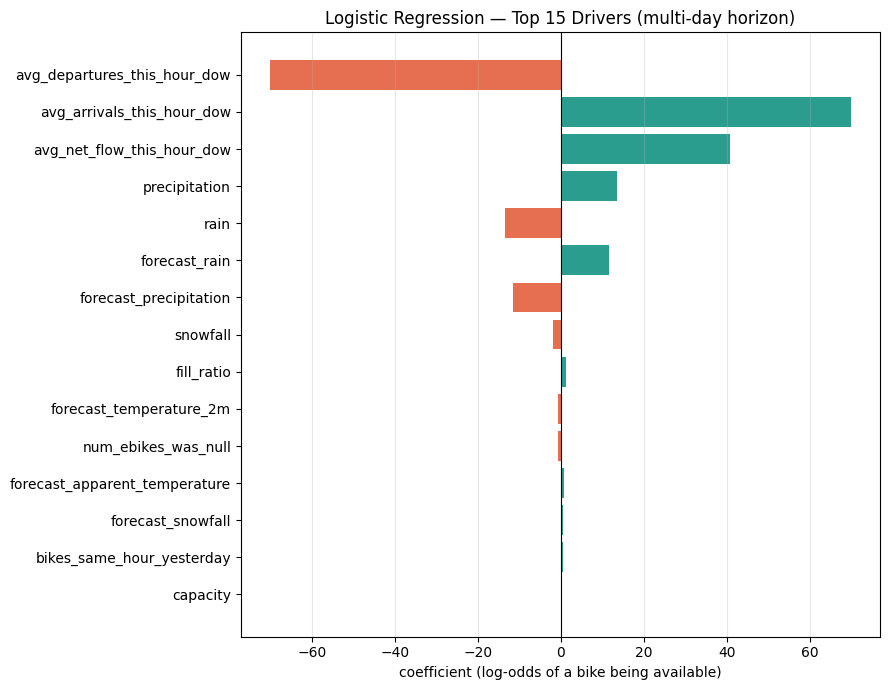

  coef chart saved -> 2.05_logit_coefficients_multi-day.png  (pseudo R²=0.1628)


In [ ]:
for h in ALL_HORIZONS:
    if h == LOGIT_HORIZON:
        continue  # 3hr already done above
    label = HORIZON_LABELS[h]
    print(f"\nCoefficient chart — {label} ...")
    df_h = load_training_data(h, years=TRAIN_YEARS)
    X_h, y_h = get_X_y(df_h, TARGET_CLASSIFICATION)
    if USE_FLOAT32:
        num_cols = X_h.select_dtypes(include=["float64", "float32"]).columns
        X_h[num_cols] = X_h[num_cols].astype("float32")
    y_h = y_h.astype("int8")
    plot_coef_chart(X_h, y_h, label)
    del df_h, X_h, y_h

# Free the statsmodels design matrices before the per-horizon loop.
del X_logit, X_logit_sm, df_tune, X_tune, y_tune

 ## Step 2 — Train and evaluate every horizon

 Now the main loop, identical discipline to 2.04 but for classification. Per horizon:
 1. Load 2019+2021 (training) and 2026 (holdout) **separately** — never concatenated,
    so the eras can't bleed into each other.
 2. Walk-forward CV on 2019+2021 with the single tuned `C` -> the CV AUC/Brier/log-loss
    estimate.
 3. Fit one final pipeline on **all** of 2019+2021, score it **once** on 2026 -> the
    holdout metrics, plus the ROC curve points (fpr/tpr) for the overlay chart.
 4. Save that final pipeline (preprocessor + model together) so the serving layer can
    load it and call `.predict_proba` directly — no feature prep to re-implement.

 One horizon at a time, ~12M rows each — six at once wouldn't fit in RAM. float32
 halves each load.

In [ ]:
results = []        # one dict per horizon
roc_points = {}     # horizon -> (fpr, tpr) on the 2026 holdout, for the ROC overlay
pr_points  = {}     # horizon -> (precision, recall, avg_precision) on the 2026 holdout

for h in HORIZONS:
    label = HORIZON_LABELS[h]
    print(f"\n{'='*70}\nHorizon {label} ({h} min)\n{'='*70}")
    t0 = time.time()

    # --- 1. Load train + holdout separately ---------------------------------
    df_tr = load_training_data(h, years=TRAIN_YEARS)
    df_ho = load_training_data(h, years=HOLDOUT_YEARS)
    X_tr, y_tr = get_X_y(df_tr, TARGET_CLASSIFICATION)
    X_ho, y_ho = get_X_y(df_ho, TARGET_CLASSIFICATION)
    y_tr = y_tr.astype("int8")
    y_ho = y_ho.astype("int8")

    if USE_FLOAT32:
        for X_ in (X_tr, X_ho):
            num_cols = X_.select_dtypes(include=["float64", "float32"]).columns
            X_[num_cols] = X_[num_cols].astype("float32")

    print(f"  train:   {len(X_tr):>10,} rows  base rate {positive_rate(y_tr):.4f}  "
          f"({df_tr['timestamp'].min().date()} -> {df_tr['timestamp'].max().date()})")
    print(f"  holdout: {len(X_ho):>10,} rows  base rate {positive_rate(y_ho):.4f}  "
          f"({df_ho['timestamp'].min().date()} -> {df_ho['timestamp'].max().date()})")

    # --- 2. Walk-forward CV on the training years ---------------------------
    print("  CV (5-fold walk-forward) ...", end=" ", flush=True)
    cv_aucs, cv_briers, cv_lls, cv_train_aucs = run_cv(X_tr, y_tr)
    cv_auc_mean,  cv_auc_std  = np.mean(cv_aucs),  np.std(cv_aucs)
    cv_brier_mean = np.mean(cv_briers)
    cv_ll_mean    = np.mean(cv_lls)
    cv_train_auc_mean = np.mean(cv_train_aucs)
    print(f"val AUC {cv_auc_mean:.4f} ± {cv_auc_std:.4f}  "
          f"train AUC {cv_train_auc_mean:.4f}  Brier {cv_brier_mean:.4f}  "
          f"(overfit gap {cv_train_auc_mean - cv_auc_mean:.4f})")

    # --- 3. Final fit on all train years, score once on 2026 ----------------
    print("  final fit on 2019+2021, scoring 2026 holdout ...", end=" ", flush=True)
    final_pipe = Pipeline([
        ("pre",   build_preprocessor("linear")),
        ("model", LogisticRegression(**BASE_LOGIT_PARAMS)),
    ])
    final_pipe.fit(X_tr, y_tr)
    ho_proba = final_pipe.predict_proba(X_ho)[:, 1]
    ho_auc, ho_brier, ho_ll = proba_metrics(y_ho, ho_proba)
    fpr, tpr, _ = roc_curve(y_ho, ho_proba)
    roc_points[h] = (fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_ho, ho_proba)
    ap = float(average_precision_score(y_ho, ho_proba))
    pr_points[h] = (prec, rec, ap)
    print(f"AUC {ho_auc:.4f}  Brier {ho_brier:.4f}  log-loss {ho_ll:.4f}  AP {ap:.4f}")

    # --- 4. Save the artifact (trained on 2019+2021 only) -------------------
    artifact_path = MODELS_DIR / f"logistic_classification_{h}min{ARTIFACT_SUFFIX}.joblib"
    joblib.dump(final_pipe, artifact_path)
    print(f"  saved -> {artifact_path.name}   ({time.time() - t0:.0f}s)")

    results.append({
        "horizon_min":    h,
        "horizon":        label,
        "base_rate":      positive_rate(y_ho),
        "cv_train_auc":   cv_train_auc_mean,
        "cv_auc":         cv_auc_mean,
        "cv_auc_std":     cv_auc_std,
        "auc_overfit_gap": cv_train_auc_mean - cv_auc_mean,
        "cv_brier":       cv_brier_mean,
        "cv_logloss":     cv_ll_mean,
        "holdout_auc":    ho_auc,
        "holdout_brier":  ho_brier,
        "holdout_logloss": ho_ll,
        "n_train":        len(X_tr),
        "n_holdout":      len(X_ho),
    })

    del df_tr, df_ho, X_tr, y_tr, X_ho, y_ho, final_pipe, ho_proba


Horizon 1hr (60 min)
  train:   12,291,918 rows  base rate 0.9390  (2019-01-01 -> 2021-12-08)
  holdout:  2,382,240 rows  base rate 0.9193  (2026-05-05 -> 2026-06-18)
  CV (5-fold walk-forward) ... convergence after 37 epochs took 61 seconds
convergence after 36 epochs took 126 seconds
convergence after 43 epochs took 231 seconds
convergence after 42 epochs took 229 seconds
convergence after 39 epochs took 210 seconds
val AUC 0.9099 ± 0.0144  train AUC 0.9330  Brier 0.0624  (overfit gap 0.0231)
  final fit on 2019+2021, scoring 2026 holdout ... convergence after 42 epochs took 481 seconds
AUC 0.9382  Brier 0.0477  log-loss 0.1636  AP 0.9937
  saved -> logistic_classification_60min.joblib   (2046s)

Horizon 3hr (180 min)
  train:   11,989,872 rows  base rate 0.9390  (2019-01-01 -> 2021-12-08)
  holdout:  2,365,366 rows  base rate 0.9193  (2026-05-05 -> 2026-06-17)
  CV (5-fold walk-forward) ... convergence after 32 epochs took 50 seconds
convergence after 39 epochs took 136 seconds
con

 ## Results table

 CV (from 2019+2021 walk-forward) next to the 2026 holdout, per horizon. What I'm
 reading:
 - **Holdout AUC ≈ CV AUC** at each horizon = the model ranks available-vs-empty
   stations just as well on data it never saw -> it generalizes across the era gap and
   nothing leaks. A holdout column far below CV is the warning sign.
 - **AUC falling as the horizon grows** is expected and honest: 1hr out, current
   availability nearly determines the answer; multi-day out, the current state has
   decayed and the model leans on weather forecasts and demand climatology, so it
   ranks less sharply.
 - **Brier rising with horizon** says the probabilities get less confident the further
   out you forecast — which is the right behavior, not a bug.

In [ ]:
res_df = pd.DataFrame(results)
pd.set_option("display.float_format", "{:.4f}".format)
show_cols = ["horizon", "base_rate", "cv_train_auc", "cv_auc", "cv_auc_std",
             "auc_overfit_gap", "holdout_auc", "cv_brier", "holdout_brier",
             "holdout_logloss", "n_train", "n_holdout"]
print(res_df[show_cols].to_string(index=False))

res_df.to_csv(FIGURES_DIR / "2.05_horizon_metrics.csv", index=False)
print("\nSaved metrics -> reports/figures/2.05_horizon_metrics.csv")

  horizon  base_rate  cv_train_auc  cv_auc  cv_auc_std  auc_overfit_gap  holdout_auc  cv_brier  holdout_brier  holdout_logloss  n_train  n_holdout
      1hr     0.9193        0.9330  0.9099      0.0144           0.0231       0.9382    0.0624         0.0477           0.1636 12291918    2382240
      3hr     0.9193        0.8933  0.8488      0.0194           0.0445       0.8887    0.0594         0.0627           0.2085 11989872    2365366
      6hr     0.9193        0.8591  0.7849      0.0784           0.0742       0.8395    0.0618         0.0687           0.2338 11668699    2338855
     12hr     0.9197        0.8435  0.7709      0.0904           0.0726       0.8709    0.0592         0.0659           0.2229 11427108    2295470
     24hr     0.9200        0.8432  0.8204      0.0135           0.0228       0.8646    0.0605         0.0658           0.2256 12445211    2235179
multi-day     0.9202        0.8068  0.7789      0.0198           0.0279       0.8294    0.0623         0.0683         

 ## ROC curves overlaid across horizons

 This is the chart that tells the classification story in one image. Each curve is the
 2026 holdout ROC for one horizon: the trade-off between catching available stations
 (true-positive rate, y) and false alarms (false-positive rate, x) as the probability
 threshold sweeps. The dashed diagonal is random guessing (AUC 0.5); the further a
 curve bows toward the top-left, the better the model separates available from empty.
 Plotting all six together makes the horizon decay visible at a glance — the 1hr curve
 should hug the top-left corner, and each longer horizon should relax toward the
 diagonal as the future gets harder to call. AUC for each is in the legend.

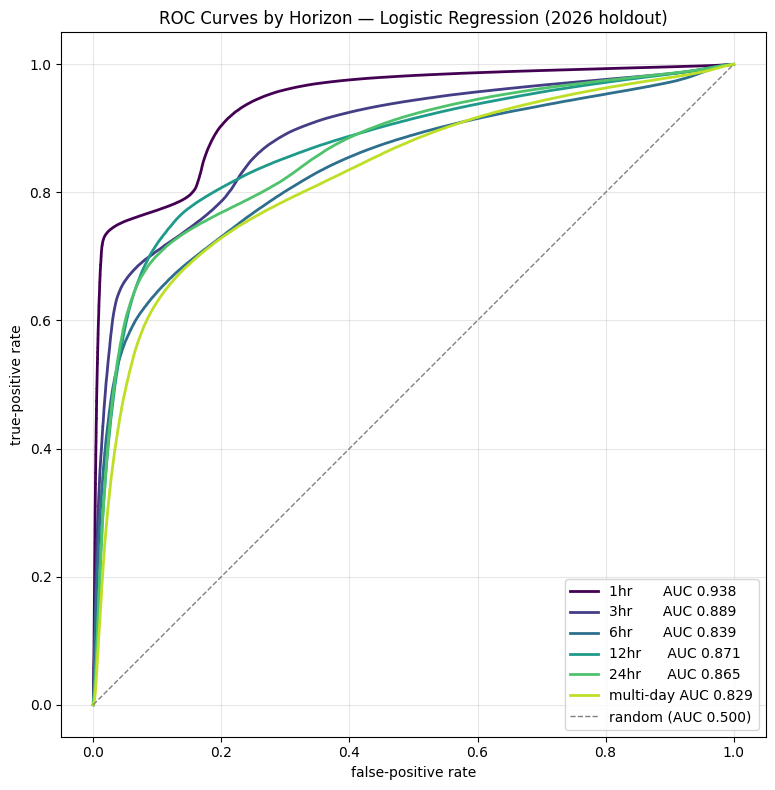

Saved -> reports/figures/2.05_roc_curves_by_horizon.png


In [ ]:
plt.figure(figsize=(8, 8))
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(HORIZONS)))
for color, h in zip(cmap, HORIZONS):
    fpr, tpr = roc_points[h]
    auc = res_df.loc[res_df["horizon_min"] == h, "holdout_auc"].iloc[0]
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{HORIZON_LABELS[h]:<9} AUC {auc:.3f}")
plt.plot([0, 1], [0, 1], ls="--", color="gray", lw=1, label="random (AUC 0.500)")
plt.xlabel("false-positive rate")
plt.ylabel("true-positive rate")
plt.title("ROC Curves by Horizon — Logistic Regression (2026 holdout)")
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "2.05_roc_curves_by_horizon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/2.05_roc_curves_by_horizon.png")

 ## CV AUC vs 2026 holdout AUC by horizon

 The leakage / era-shift check, mirroring 2.04's headline. Two lines across the 6
 horizons: CV AUC (walk-forward on 2019+2021, with a shaded ±1 std band for the
 fold-to-fold spread) and the 2026 holdout AUC scored once. Pass condition: the
 holdout line tracks the CV line. If holdout sits well below CV — especially at the
 short horizons where current availability dominates — that points at leakage or an
 era shift larger than the model absorbs.

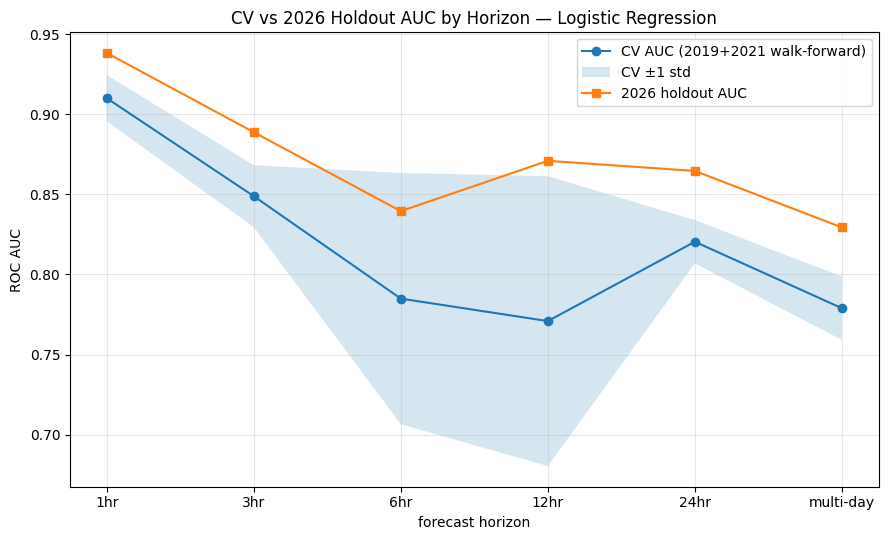

Saved -> reports/figures/2.05_cv_vs_holdout_auc.png


In [ ]:
x = np.arange(len(HORIZONS))
labels = [HORIZON_LABELS[h] for h in HORIZONS]

plt.figure(figsize=(9, 5.5))
plt.plot(x, res_df["cv_auc"], marker="o", label="CV AUC (2019+2021 walk-forward)")
plt.fill_between(
    x,
    res_df["cv_auc"] - res_df["cv_auc_std"],
    res_df["cv_auc"] + res_df["cv_auc_std"],
    alpha=0.18, label="CV ±1 std",
)
plt.plot(x, res_df["holdout_auc"], marker="s", label="2026 holdout AUC")
plt.xticks(x, labels)
plt.xlabel("forecast horizon")
plt.ylabel("ROC AUC")
plt.title("CV vs 2026 Holdout AUC by Horizon — Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "2.05_cv_vs_holdout_auc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/2.05_cv_vs_holdout_auc.png")

 ## Brier score by horizon

 AUC measures ranking; Brier measures whether the probabilities are honest (it's the
 mean squared error between the predicted probability and the 0/1 outcome — lower is
 better, 0 is perfect). This is the number that backs the app's promise: if the model
 says "70% chance of a bike" it should be right about 70% of the time. I plot the 2026
 holdout Brier per horizon — it should rise as the horizon grows (further-out forecasts
 are honestly less certain). The full calibration curve that checks whether 70% really
 means 70% is in 2.06.

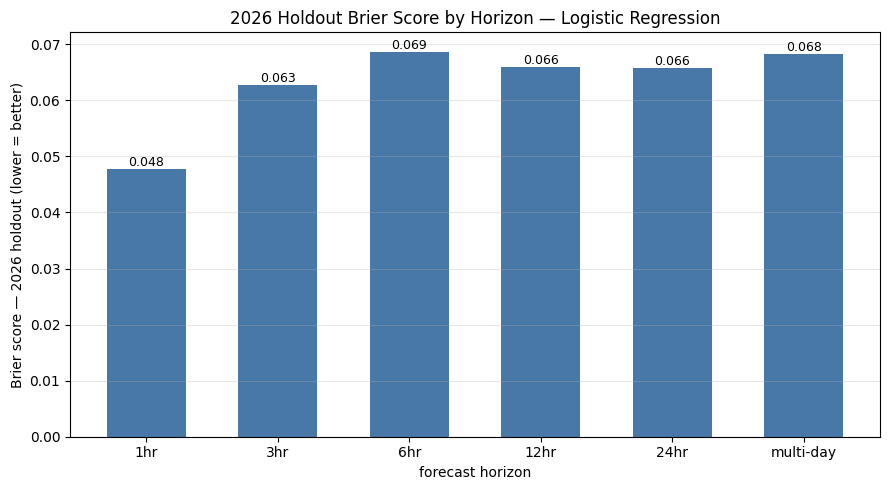

Saved -> reports/figures/2.05_holdout_brier_by_horizon.png


In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(x, res_df["holdout_brier"], width=0.6, color="#4878a8")
for xi, b in zip(x, res_df["holdout_brier"]):
    plt.text(xi, b, f"{b:.3f}", ha="center", va="bottom", fontsize=9)
plt.xticks(x, labels)
plt.xlabel("forecast horizon")
plt.ylabel("Brier score — 2026 holdout (lower = better)")
plt.title("2026 Holdout Brier Score by Horizon — Logistic Regression")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "2.05_holdout_brier_by_horizon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/2.05_holdout_brier_by_horizon.png")

 ## Precision-recall curves by horizon

 ROC/AUC treats false positives and false negatives symmetrically, but my positive
 class (bike available) dominates — most station-hours have bikes. PR curves focus
 on how well the model catches the cases that matter most: the rare empty stations.
 High precision = when I flag a station as empty, I'm usually right. High recall =
 I'm catching most of the actually-empty stations. Average Precision (AP) summarizes
 the area under the curve — higher is better, and the no-skill baseline is just the
 positive rate (the fraction of station-hours that have bikes available).

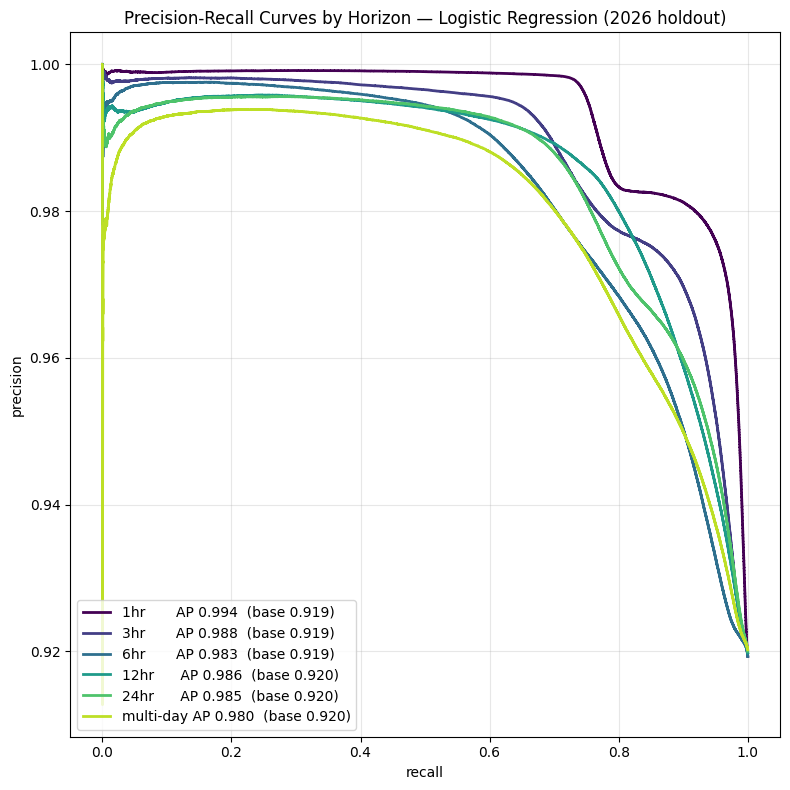

Saved -> reports/figures/2.05_pr_curves_by_horizon.png


In [ ]:
plt.figure(figsize=(8, 8))
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(HORIZONS)))
for color, h in zip(cmap, HORIZONS):
    prec, rec, ap = pr_points[h]
    base_rate = res_df.loc[res_df["horizon_min"] == h, "base_rate"].iloc[0]
    plt.plot(rec, prec, color=color, lw=2,
             label=f"{HORIZON_LABELS[h]:<9} AP {ap:.3f}  (base {base_rate:.3f})")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Precision-Recall Curves by Horizon — Logistic Regression (2026 holdout)")
plt.legend(loc="lower left", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "2.05_pr_curves_by_horizon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> reports/figures/2.05_pr_curves_by_horizon.png")

 ## Conclusion

 _(Fill in after the run — mirror 2.04's tone.)_ Points to hit once the numbers are in:
 - Does the 2026 holdout AUC track CV AUC at each horizon? (leakage / era-shift check)
 - How does AUC decay from 1hr to multi-day, and where does it cross from "useful" to
   "barely better than the base rate"?
 - The 2–3 strongest availability drivers from the Logit coefficient chart, in plain
   English (which features raise vs lower the odds a bike is there).
 - Brier behavior across horizons — confirm probabilities get honestly less confident
   further out.

 All six classification artifacts are saved to models/ as `logistic_classification_{h}min.joblib`,
 ready for the serving layer's `.predict_proba`. Deeper interpretation — the full
 coefficient table read-out, residual analysis, and the calibration curve that verifies
 the probabilities are trustworthy — is in 2.06.